In [79]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [80]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


In [81]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from MIMICUtil import *
from sklearn.decomposition import PCA

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('MIMIC_Predictors1.csv')

    top_corr = pd.read_csv('top_correlations.csv')
    columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    print(myPredictorsDf.shape)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x or 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop +  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [103]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

(724, 5068)


In [104]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [105]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [106]:
X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
X_test = X_test[X_train.columns]

In [107]:
X_train.shape

(386, 2737)

In [108]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [109]:
X_test_transf.columns

Index(['keep__keep__bin__hypothermia', 'remainder__pca0', 'remainder__pca1',
       'remainder__pca2', 'remainder__pca3', 'remainder__pca4',
       'remainder__pca5', 'remainder__pca6', 'remainder__pca7',
       'remainder__pca8',
       ...
       'remainder__pca242', 'remainder__pca243', 'remainder__pca244',
       'remainder__pca245', 'remainder__pca246', 'remainder__pca247',
       'remainder__pca248', 'remainder__pca249', 'remainder__pca250',
       'remainder__pca251'],
      dtype='object', length=253)

In [110]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    # layers.Dense(64, activation='relu'),
    # layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [111]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=30, batch_size=8, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4594 - loss: 1.4577 - roc_auc: 0.5039 - val_accuracy: 0.5361 - val_loss: 0.7075 - val_roc_auc: 0.5738
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5544 - loss: 0.9497 - roc_auc: 0.5612 - val_accuracy: 0.6446 - val_loss: 0.6561 - val_roc_auc: 0.5952
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5941 - loss: 0.8571 - roc_auc: 0.5713 - val_accuracy: 0.6446 - val_loss: 0.6320 - val_roc_auc: 0.6157
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5851 - loss: 0.8764 - roc_auc: 0.5577 - val_accuracy: 0.6627 - val_loss: 0.6185 - val_roc_auc: 0.6485
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6174 - loss: 0.7366 - roc_auc: 0.5781 - val_accuracy: 0.6687 - val_loss: 0.6088 - val_roc_auc: 0.6655
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6167 - loss: 0.7284 - roc_auc: 0.5764 - val_accuracy: 0.6807 - val_loss: 0.6062 - val_roc_auc: 0.6753
Epoc

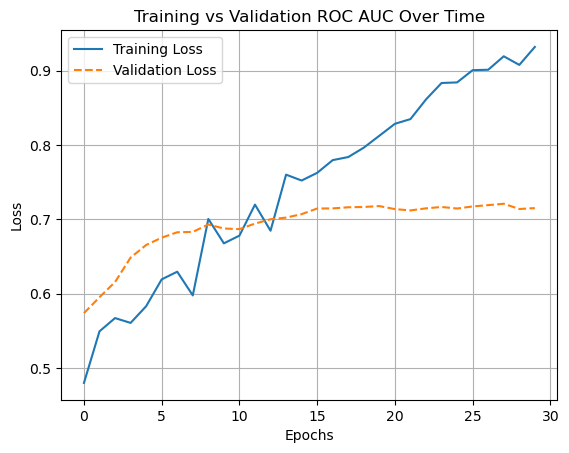

In [112]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 508us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 509us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 508us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 517us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 508us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 529us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 528us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 513us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 526us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
7982/7982 ━━━━━━━━━━━━━━━━━━━━ 4s 519us/step


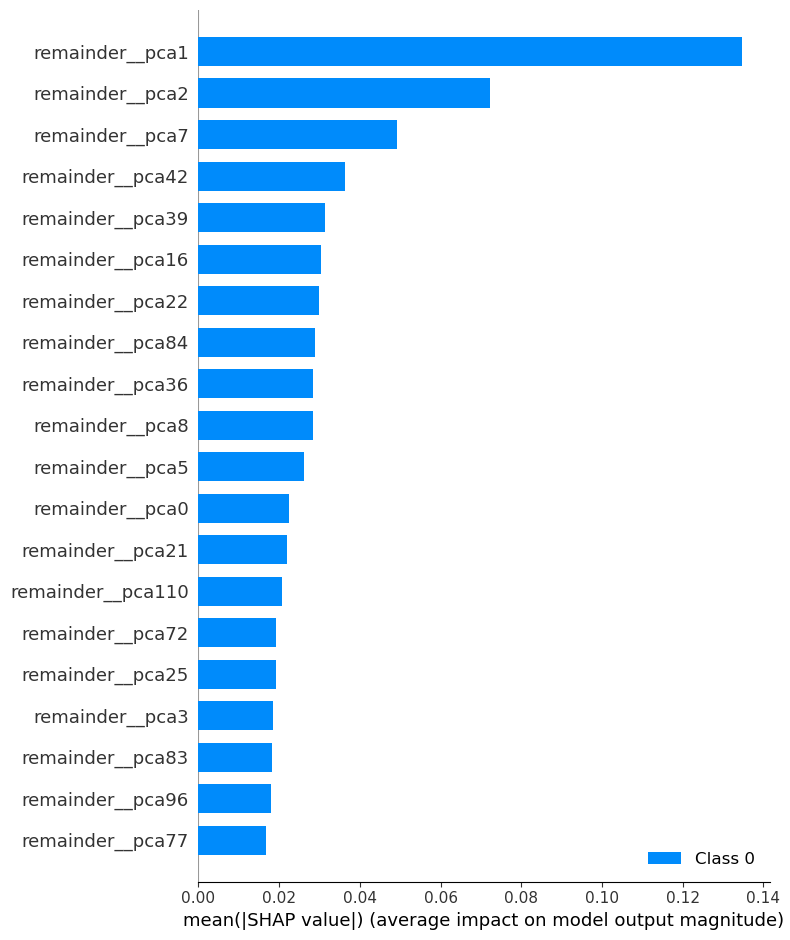

In [113]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [114]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "keep__keep__bin__hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'keep__keep__bin__hypothermia' is ranked #58 out of 253 in importance with mean(|SHAP|) = 0.0097


In [115]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
ROC AUC Score: 0.7154


In [116]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


95% CI for AUC: [0.635, 0.788]


In [117]:
myX = pd.concat([X_train_transf.reset_index().drop(columns='index'), X_test_transf.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Optimization terminated successfully.
         Current function value: 0.644125
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.643053
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.183177159301522
p-value: 0.2767101369724482
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  552
Model:                          Logit   Df Residuals:                      549
Method:                           MLE   Df Model:                            2
Date:                Fri, 18 Jul 2025   Pseudo R-squ.:                0.001271
Time:                        19:25:37   Log-Likelihood:                -355.56
converged:                       True   LL-Null:                       -356.01
Covariance Type:      

0.2767101369724482

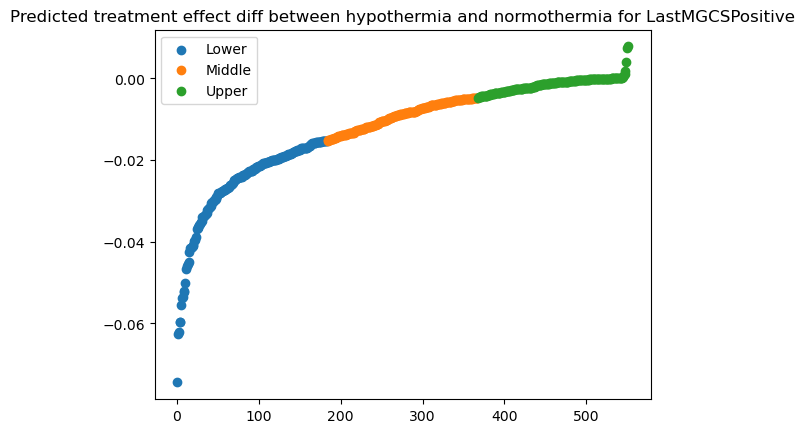

In [118]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPositive', aGroup = 'keep__keep__bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Optimization terminated successfully.
         Current function value: 0.652636
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.652179
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.3801102719141909
p-value: 0.5375442266017434
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  415
Model:                          Logit   Df Residuals:                      412
Method:                           MLE   Df Model:                            2
Date:                Fri, 18 Jul 2025   Pseudo R-squ.:                0.008523
Time:                        19:22:59   Log-Likelihood:                -270.84
converged:                       True   LL-Null:                       -273.17
Covariance Type:     

0.5375442266017434

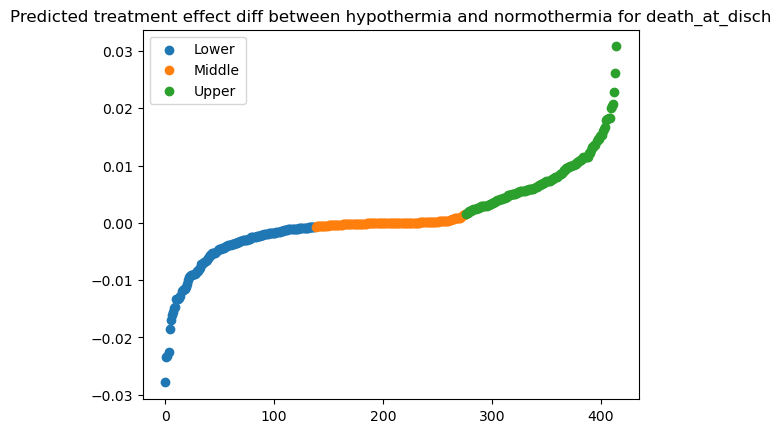

In [101]:
getTreatmentEffectDiff(aX = X_train_transf.reset_index().drop(columns='index'), aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'death_at_disch', aGroup = 'keep__keep__bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)